In [5]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

def bimodal(S=1, mu=0, sigma=1):
    choose_left = np.random.randint(2, size=S)
    z = np.random.normal(0, sigma, S)
    means = np.where(choose_left == 1, mu - 2, mu + 2)
    if S == 1: return means[0] + z[0]
    return (means + z)

def normal(S=1, mu=0, sigma=1):
    return np.random.normal(mu, sigma, S)

def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

runs = 5
N = 32
total_episodes = 50_000
save_skip = 200
learning_rate = 0.01
gamma = 1.0

# reward + gamma * np.max(qtable[new_state]) - qtable[state, action]
# qtable[state, action] += lr * delta

def run_simple(reward_func, use_huber=False):
    thetas = np.zeros((runs, total_episodes//save_skip, N))
    qtables = np.zeros((runs, total_episodes//save_skip, 1))
    tau = (np.arange(N) + 0.5) / N
    
    for n in tqdm(range(runs)):
        theta = np.zeros(N)
        qtable = 0.0
        lr = learning_rate
        
        for k in range(total_episodes):
            if k % 5000 == 0: lr *= 0.5
            
            Ttheta = reward_func() + gamma * np.zeros(N) # No future state
            u = ((Ttheta[:, None] - theta[None, :])).mean(0)

            if use_huber: rho = -np.abs(tau - (u < 0)) * du_huber(u)
            else:         rho = -(tau - (u < 0))
            theta -= lr * rho
            
            uQ = reward_func() + gamma * 0.0 - qtable
            qtable += lr * uQ
            
            if k % save_skip == 0:
                thetas[n, k//save_skip] = theta.copy()
                qtables[n, k//save_skip] = qtable
    return thetas, qtables

In [ ]:
import numpy as np
0.0 + 1.0 * np.zeros(32)

In [ ]:
def ddtheta(self, Y, theta):
    # u = (Y[:,None] - theta[None,:]).mean(0)
    # g = -(self.tau_hat - (u < 0))
    S = len(Y)
    g = np.zeros((len(theta),))
    for y in Y:
        for i, tt in enumerate(theta):
            u = y - theta[i]
            g[i] += 1 / S * (-1) * (self.tau_hat[i] - (u < 0))
    return g

In [ ]:
theta = np.zeros(N)
tau = (np.arange(N) + 0.5) / N

for k in tqdm(range(1_000)):
    Ttheta = bimodal(1) + np.zeros(N)
    
    g = np.zeros(N)
    for i in range(N):
        for j in range(N):
            g[i] += -(tau[i] - (Ttheta[j] - theta[i] < 0)) / N
    
    # S = len(Ttheta)
    # g = np.zeros((len(theta),))
    # for y in Ttheta:
    #     for i, tt in enumerate(theta):
    #         u = y - theta[i]
    #         g[i] += 1 / S * (-1) * (tau[i] - (u < 0))
    
    theta -= (1/(k+1))**0.5 * g

100%|██████████| 1000/1000 [00:00<00:00, 1601.27it/s]


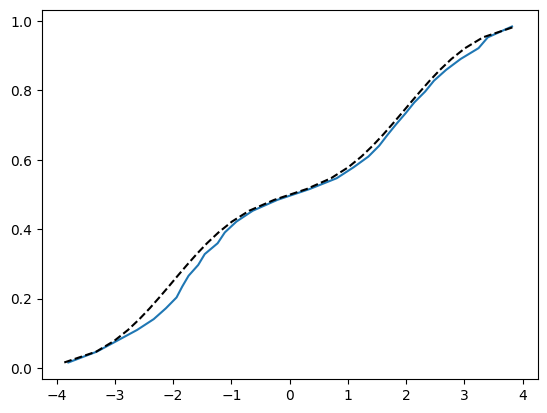

In [120]:
plt.plot(theta, tau)
plt.plot(np.quantile(np.sort(bimodal(1_000_000)), tau), tau, '--', color="black")

In [8]:
rand_func = bimodal
thetas_run, qtables_run = run_simple(rand_func)
thetas = thetas_run.mean(0)
theta = thetas[-1]

thetas_huber_run, _ = run_simple(rand_func, True)
thetas_huber = thetas_huber_run.mean(0)
theta_huber = thetas_huber[-1]

tau = (np.arange(N) + 0.5) / N
quantized_samples = np.quantile(rand_func(100_000_000), tau)

100%|██████████| 5/5 [00:06<00:00,  1.37s/it]


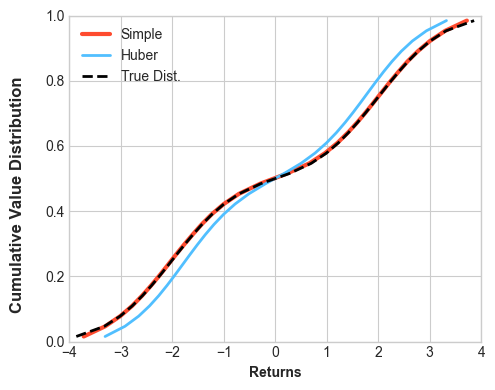

In [28]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Cumulative Value Distribution", fontweight="bold")

ax.plot(theta, tau, label="Simple", linewidth=3, color="#FE4B2F")
ax.plot(theta_huber, tau, label="Huber", linewidth=2, color="#51BFFF")
ax.plot(quantized_samples, tau, label="True Dist.", linestyle="--", linewidth=2, color="black")
ax.set_xlim(-4,4)
ax.set_ylim(0.0,1.0)
ax.set_xlabel("Returns", fontweight="bold")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("simple_cdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

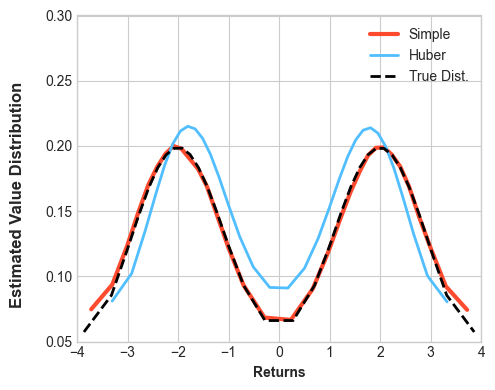

In [37]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Estimated Value Distribution", fontweight="bold")

grad = np.gradient(tau, theta)
ax.plot(theta, grad, label="Simple", linewidth=3, color="#FE4B2F")

grad = np.gradient(tau, theta_huber)
ax.plot(theta_huber, grad, label="Huber", linewidth=2, color="#51BFFF")

grad = np.gradient(tau, quantized_samples)
ax.plot(quantized_samples, grad, label="True Dist.", linestyle="--", linewidth=2, color="black")

ax.set_xlim(-4,4)
ax.set_ylim(0.05,0.3)
ax.set_xlabel("Returns", fontweight="bold")
ax.grid(True)
ax.legend(loc=1)

plt.tight_layout()
# plt.savefig("simple_pdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

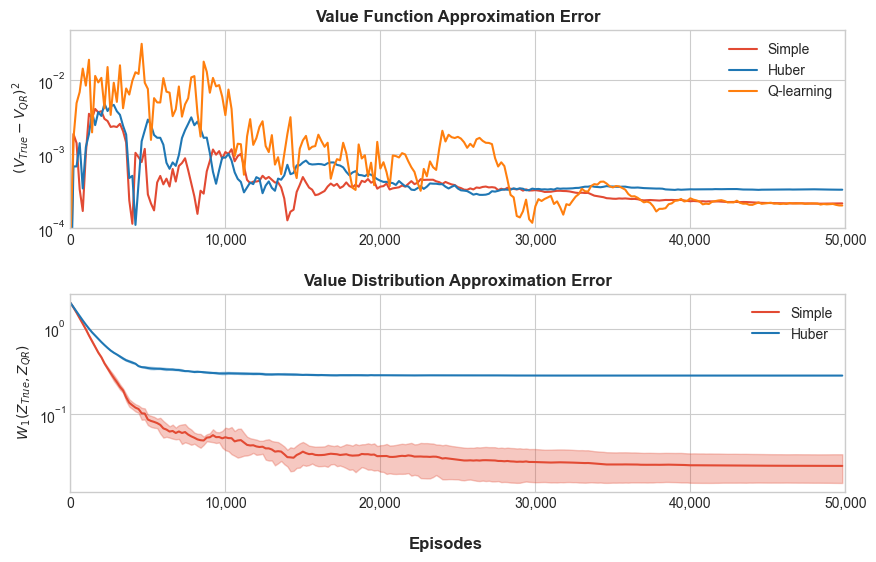

In [31]:
import seaborn as sns
from scipy.stats import t

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(10,6), gridspec_kw={'hspace': 0.33})
fig.supxlabel("Episodes", fontweight="bold")

vd = abs(quantized_samples - thetas_run).mean(-1)
vd_hub = abs(quantized_samples - thetas_huber_run).mean(-1)

vf = (0.0-thetas_run.mean(-1))**2
vf_hub = (0.0-thetas_huber_run.mean(-1))**2
vf_q = (0.0-qtables_run.mean(-1))**2

axes[1].plot(vd.mean(0), label="Simple", color="#E24A33")
axes[1].fill_between(range(total_episodes//save_skip), vd.mean(0) - vd.std(0), vd.mean(0) + vd.std(0), alpha=0.3, color="#E24A33")

axes[1].plot(vd_hub.mean(0), label="Huber")
axes[1].fill_between(range(total_episodes//save_skip), vd_hub.mean(0) - vd_hub.std(0), vd_hub.mean(0) + vd_hub.std(0), alpha=0.3)

axes[1].set_title("Value Distribution Approximation Error", fontweight="bold")
axes[1].set_yscale("log")
ticks = axes[1].get_xticks().astype(int)
axes[1].set_xticks(ticks, [f"{x:,}" for x in ticks*save_skip])
axes[1].set_xlim(ticks[1], ticks[-2])
axes[1].legend(loc=1)
axes[1].set_ylabel(" $ W_1(Z_{True}, Z_{QR}) $")


axes[0].plot(vf.mean(0), label="Simple", color="#E24A33")
axes[0].plot(vf_hub.mean(0), label="Huber")
axes[0].plot(vf_q.mean(0), label="Q-learning")

# axes[0].fill_between(range(total_episodes//save_skip), vf.mean(0) - vf.std(0), vf.mean(0) + vf.std(0), alpha=0.1, color="#E24A33")
# axes[0].fill_between(range(total_episodes//save_skip), vf_hub.mean(0) - vf_hub.std(0), vf_hub.mean(0) + vf_hub.std(0), alpha=0.1)
# axes[0].fill_between(range(total_episodes//save_skip), vf_q.mean(0) - vf_q.std(0), vf_q.mean(0) + vf_q.std(0), alpha=0.1)

axes[0].set_title("Value Function Approximation Error", fontweight="bold")
axes[0].set_yscale("log")
axes[0].set_xticks(ticks, [f"{x:,}" for x in ticks*save_skip])
axes[0].set_xlim(ticks[1], ticks[-2])
axes[0].legend(loc=1)

axes[0].set_ylim(1e-4)
axes[0].set_ylabel(" $ (V_{True} - V_{QR} )^2 $")

# plt.savefig("simple_true_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()